# 🔥 Lab 1: The Calorie Predictor — Your First ML Model!

Ever finished a workout and wondered *"how many calories did I actually burn?"* 🏋️ Your smartwatch answers that question using... **regression**. Today YOU build that model.

## 📚 What You'll Learn
- Exploring a real fitness dataset 💪
- Training a **Linear Regression** model
- Evaluating it with **MSE**
- Predicting the calories of YOUR own workout 😎

💡 **NOTE:** Pay attention — the **Golden Question 🏆** at the end depends on it!

📦 **Datasets:** `exercise.csv` + `calories.csv` — 15,000 real workout records.

In [5]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

### 🛠️ Import Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("✅ Ready to burn some calories! 🔥")

✅ Ready to burn some calories! 🔥


### 📂 Load & Merge the Data

Our data comes in TWO files: one with the workout details, one with the calories burned. They share a `User_ID` column, so we **merge** them into a single table — a very common real-world task!

In [7]:
exercise = pd.read_csv('https://raw.githubusercontent.com/iiFadel/majal-ai-track-2026/main/labs/day1/data/Exercise.csv')
calories = pd.read_csv('https://raw.githubusercontent.com/iiFadel/majal-ai-track-2026/main/labs/day1/data/Calories.csv')

df = pd.merge(exercise, calories, on='User_ID')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


### 🕵️ Section 1: Explore First! (Lab 0 skills 🐼)

Rule #1 of machine learning: **never model data you haven't looked at.**

In [8]:
print("📏 Shape:", df.shape)
df.describe()

📏 Shape: (15000, 9)


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [19]:
print(df['Duration'].max())
print(df['Calories'].mean())

30.0
89.53953333333334


### 🎯 Mini Exercise 1.1
Using `.describe()` above: what is the **longest** workout in the dataset (max Duration)? What is the **average** number of calories burned?

*Write your answers here:* ✍️
- Longest workout: 30 minutes
- Average calories: 89.5

### 📊 Section 2: Hunting for Relationships

Regression is all about relationships: *when X goes up, what happens to y?* Let's plot **Duration vs Calories** — every dot is one person's workout.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


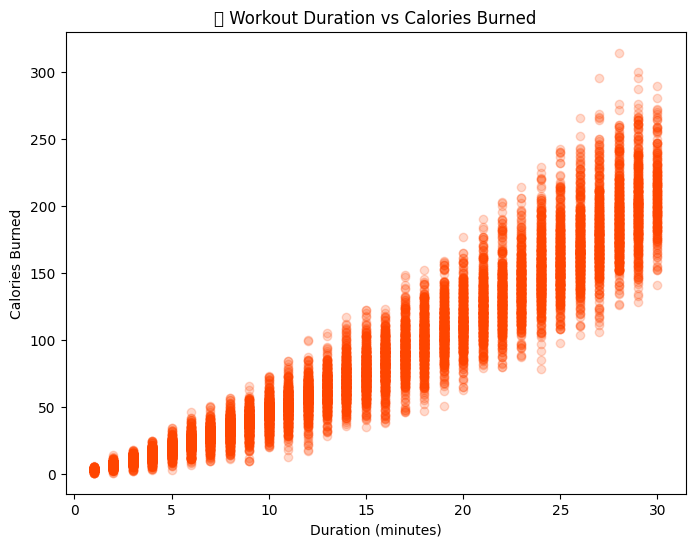

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Duration'], df['Calories'], alpha=0.2, color='orangered')
plt.title('🔥 Workout Duration vs Calories Burned')
plt.xlabel('Duration (minutes)')
plt.ylabel('Calories Burned')
plt.show()

# 👀 WOW — look at that pattern! Longer workout → more calories. Almost a straight line!

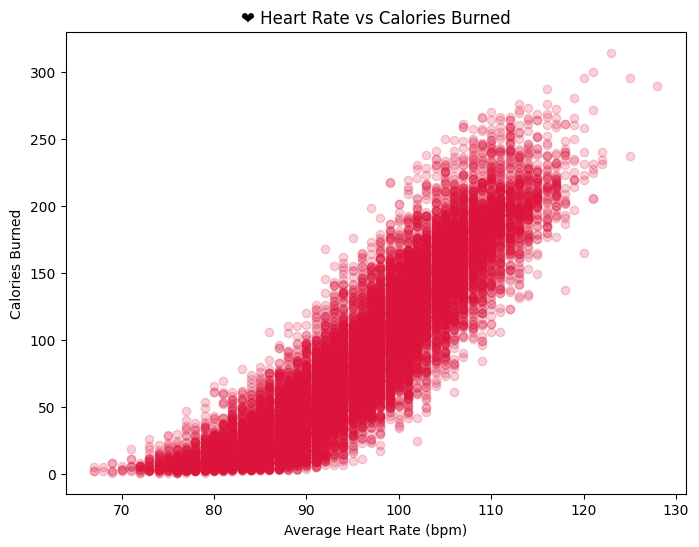

In [10]:
# Another candidate: Heart Rate ❤️
plt.figure(figsize=(8, 6))
plt.scatter(df['Heart_Rate'], df['Calories'], alpha=0.2, color='crimson')
plt.title('❤️ Heart Rate vs Calories Burned')
plt.xlabel('Average Heart Rate (bpm)')
plt.ylabel('Calories Burned')
plt.show()

### 🎯 Mini Exercise 2.1
Make a scatter plot of **Body_Temp vs Calories**. Does the relationship look strong or weak compared to Duration? 🌡️

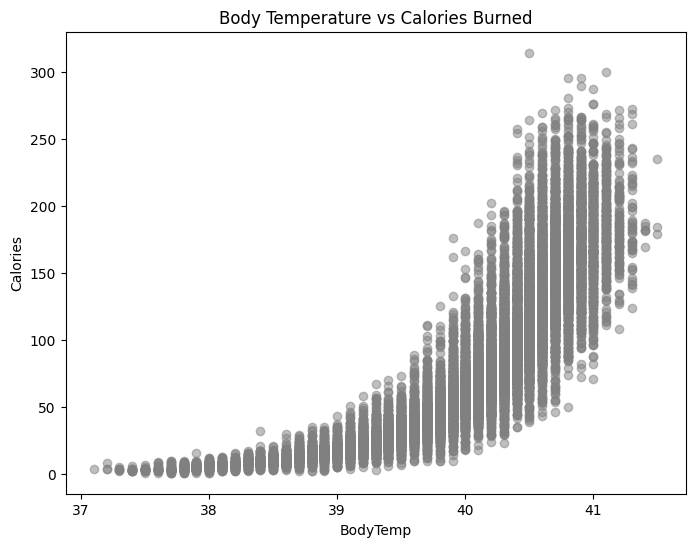

In [22]:
# Create a scatter plot of Body Temperature against Calories
plt.figure(figsize=(8, 6))
plt.scatter(df['Body_Temp'], df['Calories'], alpha=0.5, color='Gray')
plt.title('BodyTemp vs Calories')
plt.xlabel('BodyTemp')
plt.ylabel('Calories')
plt.show()

### 🤖 Section 3: Train Your First Model!

We'll start simple: predict Calories using **only Duration**. Remember the theory:

$$calories = m \times duration + b$$

The model's job during training is to find the best **m** (slope) and **b** (intercept).

And remember the **train/test split**: we hide 20% of the data from the model, like exam questions the student never saw. 📝

In [12]:
X = df[['Duration']]   # feature (input)
y = df['Calories']     # label (what we predict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🏋️ Training workouts: {len(X_train)}")
print(f"📝 Test workouts (hidden from the model): {len(X_test)}")

🏋️ Training workouts: 12000
📝 Test workouts (hidden from the model): 3000


In [23]:
model = LinearRegression()
model.fit(X_train, y_train)   # 🎓 this is where the LEARNING happens!

m = model.coef_[0] #slop
b = model.intercept_ #bias
print(f"🧠 The model learned:  calories = {m:.2f} × minutes + ({b:.2f})")
print(f"💡 In human language: every extra minute burns about {m:.1f} calories!")

🧠 The model learned:  calories = 7.15 × minutes + (-21.67)
💡 In human language: every extra minute burns about 7.2 calories!


### 📏 Section 4: How Good Is It? (MSE time)

⚠️ **Important:** we evaluate on the **test set** — data the model has never seen. Testing on training data is like grading a student on the practice questions they memorized!

In [14]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"📉 Mean Squared Error: {mse:.1f}")
print(f"📏 On average, predictions are off by about ±{mse ** 0.5:.0f} calories")

📉 Mean Squared Error: 345.0
📏 On average, predictions are off by about ±19 calories


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


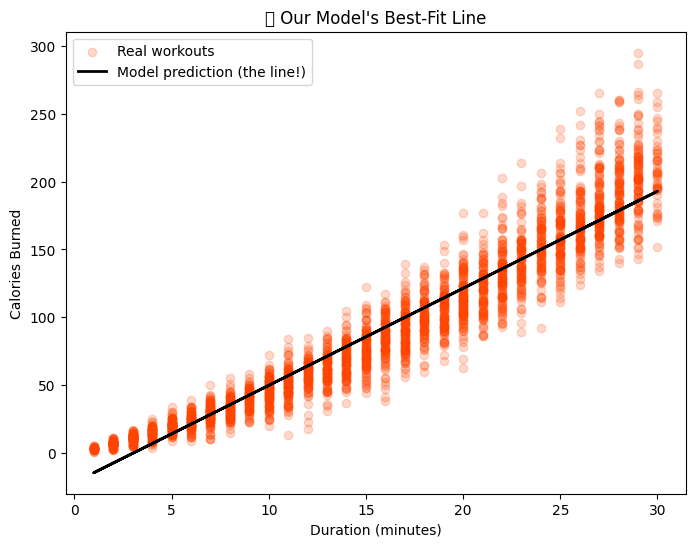

In [15]:
# Let's SEE the line the model learned 📈
plt.figure(figsize=(8, 6))
plt.scatter(X_test['Duration'], y_test, alpha=0.2, color='orangered', label='Real workouts')
plt.plot(X_test['Duration'], y_pred, color='black', linewidth=2, label='Model prediction (the line!)')
plt.title('🤖 Our Model\'s Best-Fit Line')
plt.xlabel('Duration (minutes)')
plt.ylabel('Calories Burned')
plt.legend()
plt.show()

### 🚀 Section 5: Upgrade the Model — More Features!

Duration alone is good, but your smartwatch also knows your **heart rate, age, weight**... Let's give our model the same information and see if the error drops. 📉

In [16]:
features = ['Duration', 'Heart_Rate', 'Age', 'Weight', 'Body_Temp']
X2 = df[features]

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y_train)

y2_pred = model2.predict(X2_test)
mse2 = mean_squared_error(y_test, y2_pred)

print(f"📉 MSE with Duration only:      {mse:.1f}")
print(f"📉 MSE with 5 features:         {mse2:.1f}")
print(f"🎉 Improvement: {(1 - mse2/mse) * 100:.0f}% less error!")

📉 MSE with Duration only:      345.0
📉 MSE with 5 features:         132.7
🎉 Improvement: 62% less error!


### 😎 Section 6: Predict YOUR Workout

Time for the fun part. Fill in your own numbers from your last workout (or make them up 😄) and let YOUR model predict your calories!

In [25]:
# TO-DO: change these numbers to YOUR workout! 🏋️
my_workout = pd.DataFrame({
    'Duration':   [30],    # minutes
    'Heart_Rate': [110],   # average bpm
    'Age':        [21],    # years
    'Weight':     [60],    # kg
    'Body_Temp':  [37]   # °C during exercise (normal is ~40 while training)
})

prediction = model2.predict(my_workout)[0]
print(f"🔥 Your model says you burned about {prediction:.0f} calories! 💪")

🔥 Your model says you burned about 253 calories! 💪


### 🎯 Mini Exercise 6.1 — Break the Model! 😈
Try predicting a **0-minute** workout (set Duration to 0, keep the rest). What does the model say? Does the answer make sense? Keep this in mind for the Golden Question...

In [24]:
# TO-DO: predict a workout with Duration = 0. What do you get? 🤔
my_workout = pd.DataFrame({
    'Duration':   [0],    # minutes
    'Heart_Rate': [110],   # average bpm
    'Age':        [20],    # years
    'Weight':     [70],    # kg
    'Body_Temp':  [40.0]   # °C during exercise (normal is ~40 while training)
})

prediction = model2.predict(my_workout)[0]
print(f"🔥 Your model says you burned about {prediction:.0f} calories! 💪")

🔥 Your model says you burned about 4 calories! 💪


## The GOLDEN Question 🏆

You (probably) just saw the model predict a **weird number** for a 0-minute workout — maybe even *negative calories* 😱.

**Why does this happen? Can we always trust a model's prediction for inputs very different from the data it was trained on?**

*Hint: think about the straight line — it extends forever in both directions, but our data doesn't...*